# GoogLeNet

In [1]:
!pip install wandb -q

In [2]:
from kaggle_secrets import UserSecretsClient
import wandb

secrets = UserSecretsClient()
wandb.login(key=secrets.get_secret("WANDB_API_KEY"))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gdzag22 (gdzag22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Data Loading

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

df = pd.read_csv('/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv')
df.columns = df.columns.str.strip()

train_df = df[df['Usage'] == 'Training'].reset_index(drop=True)
val_df   = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)
test_df  = df[df['Usage'] == 'PrivateTest'].reset_index(drop=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Device:", device)

Train: 28709 Val: 3589 Test: 3589
Device: cuda


In [4]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        pixels = np.array(self.dataframe.iloc[idx]['pixels'].split(),
                          dtype=np.uint8).reshape(48, 48)
        image = Image.fromarray(pixels)
        if self.transform:
            image = self.transform(image)
        label = int(self.dataframe.iloc[idx]['emotion'])
        return image, label

augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(48, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = FERDataset(train_df, transform=augmented_transform)
val_dataset = FERDataset(val_df, transform=val_transform)
test_dataset = FERDataset(test_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
print("One batch shape:", next(iter(train_loader))[0].shape)

One batch shape: torch.Size([64, 1, 48, 48])


# Forward Sanity Check

In [5]:
expected_loss = np.log(7)
print(f"Expected initial loss: {expected_loss:.4f}")

test_model = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(32 * 48 * 48, 7)
).to(device)

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    out = test_model(images)
    loss = nn.CrossEntropyLoss()(out, labels)

print(f"Actual initial loss:   {loss.item():.4f}")

# Backward check
small_images = images[:10]
small_labels = labels[:10]

optimizer_test = torch.optim.Adam(test_model.parameters(), lr=0.01)
losses = []
for step in range(200):
    optimizer_test.zero_grad()
    out = test_model(small_images)
    loss = nn.CrossEntropyLoss()(out, small_labels)
    loss.backward()
    optimizer_test.step()
    losses.append(loss.item())

print(f"Loss after overfitting 10 samples: {losses[-1]:.4f}")

Expected initial loss: 1.9459
Actual initial loss:   1.9226
Loss after overfitting 10 samples: 0.0000


# Training Utilities

In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


def run_experiment(model, run_name, epochs=40, lr=0.001, weight_decay=1e-4):
    run = wandb.init(
        project="facial_expression_recognition",
        group="GoogLeNet",
        name=run_name,
        config={
            'epochs': epochs,
            'lr': lr,
            'optimizer': 'Adam',
            'weight_decay': weight_decay,
            'scheduler': 'CosineAnnealing',
            'augmentation': True,
            'batch_size': 64
        }
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_accs, val_accs, train_losses, val_losses = [], [], [], []
    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'lr': optimizer.param_groups[0]['lr']
        })

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    np.save(f'/kaggle/working/{run_name}.npy', [train_accs, val_accs, train_losses, val_losses])
    wandb.finish()
    return train_accs, val_accs, train_losses, val_losses, best_model_state

# training

###  Baseline

In [7]:
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_1x1, out_3x3_reduce, out_3x3, out_5x5_reduce, out_5x5, out_pool):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out_1x1, kernel_size=1),
            nn.BatchNorm2d(out_1x1),
            nn.ReLU()
        )

        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, out_3x3_reduce, kernel_size=1),
            nn.BatchNorm2d(out_3x3_reduce),
            nn.ReLU(),
            nn.Conv2d(out_3x3_reduce, out_3x3, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_3x3),
            nn.ReLU()
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, out_5x5_reduce, kernel_size=1),
            nn.BatchNorm2d(out_5x5_reduce),
            nn.ReLU(),
            nn.Conv2d(out_5x5_reduce, out_5x5, kernel_size=5, padding=2),
            nn.BatchNorm2d(out_5x5),
            nn.ReLU()
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_pool, kernel_size=1),
            nn.BatchNorm2d(out_pool),
            nn.ReLU()
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], dim=1)


class GoogLeNet(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.bn1= nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.inception1 = InceptionModule(32, 16, 8, 32, 4, 8, 8)
        self.inception2 = InceptionModule(64, 32, 16, 64, 8, 16, 16)
        self.inception3 = InceptionModule(128, 64, 32, 128, 16, 32, 32)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(256, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))  
        x = self.inception1(x)
        x = self.pool(x)                                    
        x = self.inception2(x)
        x = self.pool(x)                                    
        x = self.inception3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        return self.fc(x)

model_v1 = GoogLeNet().to(device)
v1_train_accs, v1_val_accs, v1_train_losses, v1_val_losses, v1_best_state = run_experiment(
    model_v1, 'GoogLeNet_v1_baseline', epochs=40
)

Epoch 1/40 | Train Acc: 0.3332 | Val Acc: 0.3773 | LR: 0.000998
Epoch 2/40 | Train Acc: 0.4490 | Val Acc: 0.4327 | LR: 0.000994
Epoch 3/40 | Train Acc: 0.4816 | Val Acc: 0.4943 | LR: 0.000986
Epoch 4/40 | Train Acc: 0.5032 | Val Acc: 0.4648 | LR: 0.000976
Epoch 5/40 | Train Acc: 0.5172 | Val Acc: 0.4943 | LR: 0.000962
Epoch 6/40 | Train Acc: 0.5272 | Val Acc: 0.5116 | LR: 0.000946
Epoch 7/40 | Train Acc: 0.5353 | Val Acc: 0.5495 | LR: 0.000926
Epoch 8/40 | Train Acc: 0.5438 | Val Acc: 0.5453 | LR: 0.000905
Epoch 9/40 | Train Acc: 0.5507 | Val Acc: 0.5559 | LR: 0.000880
Epoch 10/40 | Train Acc: 0.5547 | Val Acc: 0.5428 | LR: 0.000854
Epoch 11/40 | Train Acc: 0.5585 | Val Acc: 0.5631 | LR: 0.000825
Epoch 12/40 | Train Acc: 0.5632 | Val Acc: 0.5695 | LR: 0.000794
Epoch 13/40 | Train Acc: 0.5685 | Val Acc: 0.5628 | LR: 0.000761
Epoch 14/40 | Train Acc: 0.5707 | Val Acc: 0.5706 | LR: 0.000727
Epoch 15/40 | Train Acc: 0.5746 | Val Acc: 0.5812 | LR: 0.000691
Epoch 16/40 | Train Acc: 0.5784 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▆▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▄▄▅▆▆▆▆▇▇▇▇▇▇▆▇▇▇▇▇▇█▇███████████████
val_loss,█▇▅▅▄▄▃▃▃▃▂▃▂▂▂▂▄▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,0
train_acc,0.62367
train_loss,0.99296
val_acc,0.60741


### Deeper GoogLeNet

In [8]:
class GoogLeNet_v2(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.inception1 = InceptionModule(64, 32, 16, 64, 8, 16, 16)
        self.inception2 = InceptionModule(128, 64, 32, 128, 16, 32, 32)
        self.inception3 = InceptionModule(256, 96, 48, 192, 24, 48, 64)
        self.inception4 = InceptionModule(400, 96, 48, 192, 24, 48, 64)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(400, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))  
        x = self.inception1(x)
        x = self.pool(x)                                    
        x = self.inception2(x)
        x = self.pool(x)                                    
        x = self.inception3(x)
        x = self.inception4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        return self.fc(x)

model_v2 = GoogLeNet_v2().to(device)
v2_train_accs, v2_val_accs, v2_train_losses, v2_val_losses, v2_best_state = run_experiment(
    model_v2, 'GoogLeNet_v2_deeper', epochs=50, weight_decay=1e-4
)

Epoch 1/50 | Train Acc: 0.4094 | Val Acc: 0.4845 | LR: 0.000999
Epoch 2/50 | Train Acc: 0.5185 | Val Acc: 0.4472 | LR: 0.000996
Epoch 3/50 | Train Acc: 0.5470 | Val Acc: 0.5350 | LR: 0.000991
Epoch 4/50 | Train Acc: 0.5693 | Val Acc: 0.5419 | LR: 0.000984
Epoch 5/50 | Train Acc: 0.5837 | Val Acc: 0.5695 | LR: 0.000976
Epoch 6/50 | Train Acc: 0.5956 | Val Acc: 0.5826 | LR: 0.000965
Epoch 7/50 | Train Acc: 0.6077 | Val Acc: 0.5773 | LR: 0.000952
Epoch 8/50 | Train Acc: 0.6128 | Val Acc: 0.5963 | LR: 0.000938
Epoch 9/50 | Train Acc: 0.6169 | Val Acc: 0.6060 | LR: 0.000922
Epoch 10/50 | Train Acc: 0.6265 | Val Acc: 0.6013 | LR: 0.000905
Epoch 11/50 | Train Acc: 0.6315 | Val Acc: 0.6191 | LR: 0.000885
Epoch 12/50 | Train Acc: 0.6389 | Val Acc: 0.6138 | LR: 0.000864
Epoch 13/50 | Train Acc: 0.6455 | Val Acc: 0.6046 | LR: 0.000842
Epoch 14/50 | Train Acc: 0.6496 | Val Acc: 0.6002 | LR: 0.000819
Epoch 15/50 | Train Acc: 0.6557 | Val Acc: 0.6269 | LR: 0.000794
Epoch 16/50 | Train Acc: 0.6633 | 

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,███████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████████
train_loss,█▆▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▂▁▄▄▅▅▆▆▆▆▆▇▆▆▇▇▇▇▇▇▇▇▇█████████████████
val_loss,▅█▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▂▁▁▁▂▁▁▁▁▂▂▂▂▂▂▂▂▂▂
epoch,50
lr,0
train_acc,0.78282
train_loss,0.58388
val_acc,0.66927


### Best Config

In [9]:
model_v3 = GoogLeNet_v2(dropout=0.3).to(device)
v3_train_accs, v3_val_accs, v3_train_losses, v3_val_losses, v3_best_state = run_experiment(
    model_v3, 'GoogLeNet_v3_dropout03', epochs=50, weight_decay=1e-4
)

Epoch 1/50 | Train Acc: 0.3964 | Val Acc: 0.4411 | LR: 0.000999
Epoch 2/50 | Train Acc: 0.5164 | Val Acc: 0.5085 | LR: 0.000996
Epoch 3/50 | Train Acc: 0.5487 | Val Acc: 0.5587 | LR: 0.000991
Epoch 4/50 | Train Acc: 0.5691 | Val Acc: 0.5458 | LR: 0.000984
Epoch 5/50 | Train Acc: 0.5824 | Val Acc: 0.5052 | LR: 0.000976
Epoch 6/50 | Train Acc: 0.5931 | Val Acc: 0.5787 | LR: 0.000965
Epoch 7/50 | Train Acc: 0.6043 | Val Acc: 0.5670 | LR: 0.000952
Epoch 8/50 | Train Acc: 0.6105 | Val Acc: 0.5977 | LR: 0.000938
Epoch 9/50 | Train Acc: 0.6183 | Val Acc: 0.6063 | LR: 0.000922
Epoch 10/50 | Train Acc: 0.6276 | Val Acc: 0.6071 | LR: 0.000905
Epoch 11/50 | Train Acc: 0.6328 | Val Acc: 0.5968 | LR: 0.000885
Epoch 12/50 | Train Acc: 0.6391 | Val Acc: 0.5960 | LR: 0.000864
Epoch 13/50 | Train Acc: 0.6418 | Val Acc: 0.6030 | LR: 0.000842
Epoch 14/50 | Train Acc: 0.6484 | Val Acc: 0.6258 | LR: 0.000819
Epoch 15/50 | Train Acc: 0.6538 | Val Acc: 0.6236 | LR: 0.000794
Epoch 16/50 | Train Acc: 0.6618 | 

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,███████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▆▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▄▃▅▆▆▆▆▆▇▇▆▆▇▇▇▇▇▇█▇█▇▇███▇██████████
val_loss,█▅▄▄▅▂▂▃▂▂▁▂▂▂▁▂▁▁▁▁▁▂▁▁▁▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂
epoch,50
lr,0
train_acc,0.78738
train_loss,0.57859
val_acc,0.66453


# Analysis

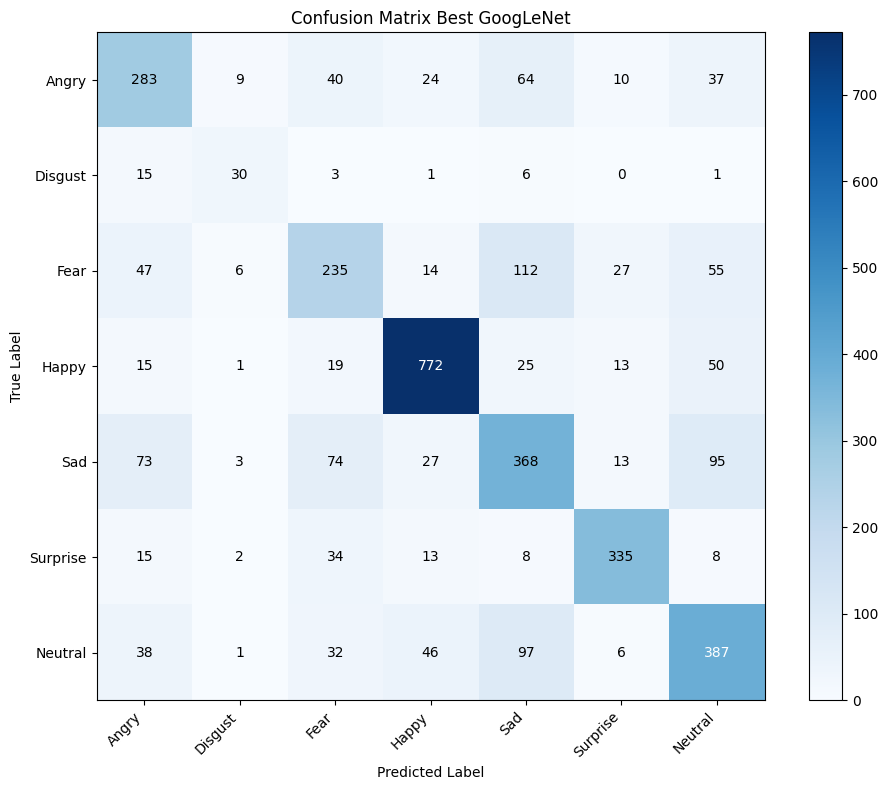

In [10]:
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

model_v2.load_state_dict(v2_best_state)
model_v2.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_v2(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.set_xticklabels(emotion_labels, rotation=45, ha='right')
ax.set_yticklabels(emotion_labels)

for i in range(7):
    for j in range(7):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_title('Confusion Matrix Best GoogLeNet')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/googlenet_confusion_matrix.png', dpi=150)
plt.show()

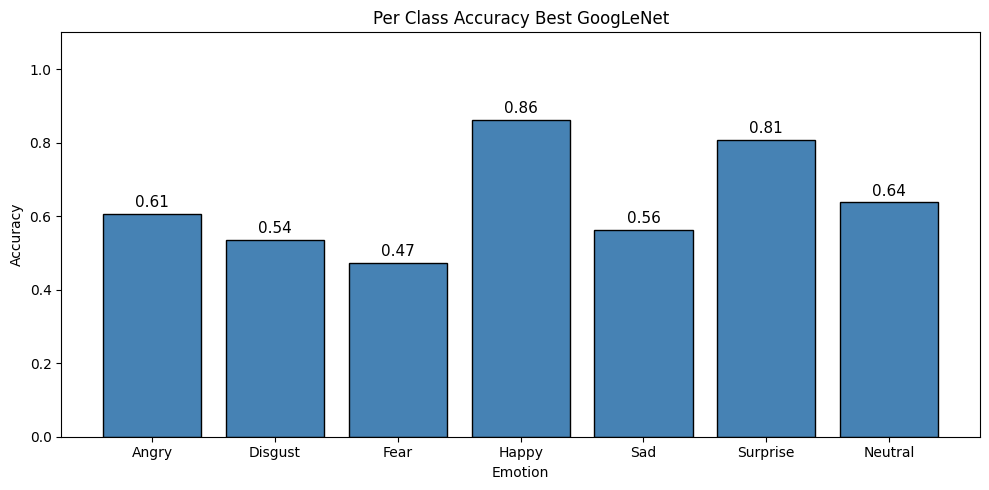

In [11]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(emotion_labels, per_class_acc, color='steelblue', edgecolor='black')

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=11)

ax.set_title('Per Class Accuracy Best GoogLeNet')
ax.set_xlabel('Emotion')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('/kaggle/working/googlenet_per_class_accuracy.png', dpi=150)
plt.show()